[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meaw-star/TUGAS_STATISTIKA_UAS/blob/main/Meuthia_Sari_Rusdy_F5212510027.ipynb)

# Analisis Regresi Linear Berganda untuk Memprediksi Jumlah Perceraian di Indonesia Berdasarkan Pengeluaran Per Kapita, Tingkat Pengangguran Terbuka, dan Persentase Penduduk Miskin Tahun 2022–2025 Menggunakan Regresi Linear Berganda

#  Data Collecting

Dataset yang digunakan merupakan data jumlah perceraian, pengeluaran per kapita, tingkat pengangguran terbuka, dan persentase penduduk miskin menurut provinsi di Indonesia dari tahun 2022 hingga 2025 berdasarkan data dari BPS (Badan Pusat Statistik). Dataset ini memuat informasi mengenai pengeluaran per kapita disesuaikan, tingkat pengangguran terbuka, persentase penduduk miskin, dan jumlah perkara perceraian di setiap provinsi.

**Variabel yang digunakan:**
- **Variabel Target (Y):** `Y_Jumlah_Perceraian` — Jumlah perkara perceraian
- **Variabel Prediktor (X):**
  - `X1_Pengeluaran_Per_Kapita` — Pengeluaran per kapita disesuaikan (Ribu Rp/Org/Thn)
  - `X2_TPT` — Tingkat pengangguran terbuka (%)
  - `X3_Penduduk_Miskin` — Persentase penduduk miskin (%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = "Dataset_Perceraian_Indonesia_2022-2025.csv"
df_raw = pd.read_csv(file_path, header=3)
df_raw.columns = ['No', 'Provinsi', 'Tahun', 'Y_Jumlah_Perceraian', 'X1_Pengeluaran_Per_Kapita', 'X2_TPT', 'X3_Penduduk_Miskin']
df_raw['Provinsi'] = df_raw['Provinsi'].ffill()
df = df_raw.dropna(subset=['Y_Jumlah_Perceraian', 'Tahun']).copy()
df = df[['Provinsi', 'Tahun', 'Y_Jumlah_Perceraian', 'X1_Pengeluaran_Per_Kapita', 'X2_TPT', 'X3_Penduduk_Miskin']].reset_index(drop=True)
df['Tahun'] = df['Tahun'].astype(int)

print("Dataset berhasil dimuat!")

Dataset berhasil dimuat!


#  Exploratory Data Analysis (EDA)

In [3]:
print("=== 5 Data Pertama ===")
df.head()

=== 5 Data Pertama ===


,Provinsi,Tahun,Y_Jumlah_Perceraian,X1_Pengeluaran_Per_Kapita,X2_TPT,X3_Penduduk_Miskin
0,Aceh,2022,6904.0,9963.0,6.17,14.64
1,Aceh,2023,6086.0,10334.0,6.03,14.45
2,Aceh,2024,6103.0,10811.0,5.75,12.64
3,Aceh,2025,6471.0,11191.0,5.64,12.22
4,Sumatera Utara,2022,17333.0,10848.0,6.16,8.42


In [4]:
print("=== Statistik Deskriptif ===")
df.describe()

=== Statistik Deskriptif ===


,Tahun,Y_Jumlah_Perceraian,X1_Pengeluaran_Per_Kapita,X2_TPT,X3_Penduduk_Miskin
count,116.000000,116.000000,116.000000,116.000000,116.000000
mean,2023.500000,14418.706897,11751.568966,4.629914,9.587241
std,1.122884,23777.952095,2175.707186,1.307812,4.512769
min,2022.000000,471.000000,7146.000000,2.580000,3.730000
25%,2022.750000,3144.750000,10749.000000,3.525000,6.167500
50%,2023.500000,6241.500000,11518.000000,4.310000,8.525000
75%,2024.250000,12935.250000,12447.750000,5.605000,11.885000
max,2025.000000,98903.000000,20676.000000,8.310000,26.560000


In [5]:
print("=== Informasi Dataset ===")
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Provinsi                   116 non-null    object 
 1   Tahun                      116 non-null    int64  
 2   Y_Jumlah_Perceraian        116 non-null    float64
 3   X1_Pengeluaran_Per_Kapita  116 non-null    float64
 4   X2_TPT                     116 non-null    float64
 5   X3_Penduduk_Miskin         116 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.6+ KB


In [6]:
print(f"Jumlah baris (observasi) : {df.shape[0]}")
print(f"Jumlah kolom (variabel)  : {df.shape[1]}")
print(f"Jumlah provinsi          : {df['Provinsi'].nunique()}")
print(f"Rentang tahun            : {df['Tahun'].min()} - {df['Tahun'].max()}")

Jumlah baris (observasi) : 116
Jumlah kolom (variabel)  : 6
Jumlah provinsi          : 29
Rentang tahun            : 2022 - 2025


In [7]:
print("=== Jumlah Nilai Kosong per Kolom ===")
print(df.isnull().sum())

=== Jumlah Nilai Kosong per Kolom ===
Provinsi                     0
Tahun                        0
Y_Jumlah_Perceraian          0
X1_Pengeluaran_Per_Kapita    0
X2_TPT                       0
X3_Penduduk_Miskin           0
dtype: int64


In [8]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


==== Deteksi Outlier dengan IQR pada kolom Y_Jumlah_Perceraian ====
Batas Bawah : -11541.0
Batas Atas  : 27621.0
Jumlah Y_Jumlah_Perceraian Outlier : 12 baris dari total 116 baris data


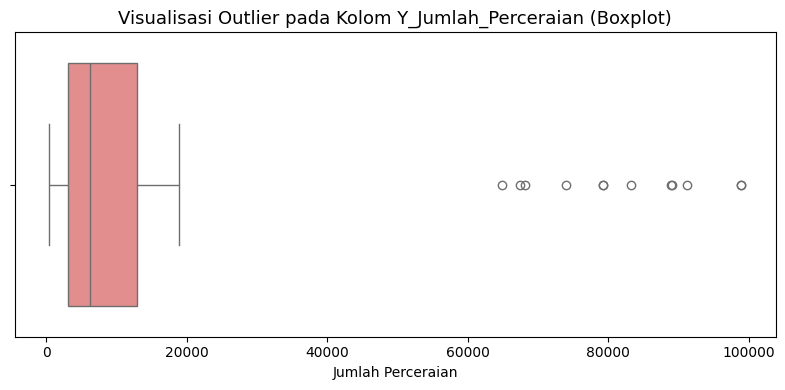

In [9]:
kolom_target = 'Y_Jumlah_Perceraian'

print(f"==== Deteksi Outlier dengan IQR pada kolom {kolom_target} ====")

Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[kolom_target] < lower_bound) | (df[kolom_target] > upper_bound)]
print(f"Batas Bawah : {lower_bound}")
print(f"Batas Atas  : {upper_bound}")
print(f"Jumlah {kolom_target} Outlier : {len(outliers)} baris dari total {len(df)} baris data")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[kolom_target], color='lightcoral')
plt.title(f'Visualisasi Outlier pada Kolom {kolom_target} (Boxplot)', fontsize=13)
plt.xlabel('Jumlah Perceraian')
plt.tight_layout()
plt.show()

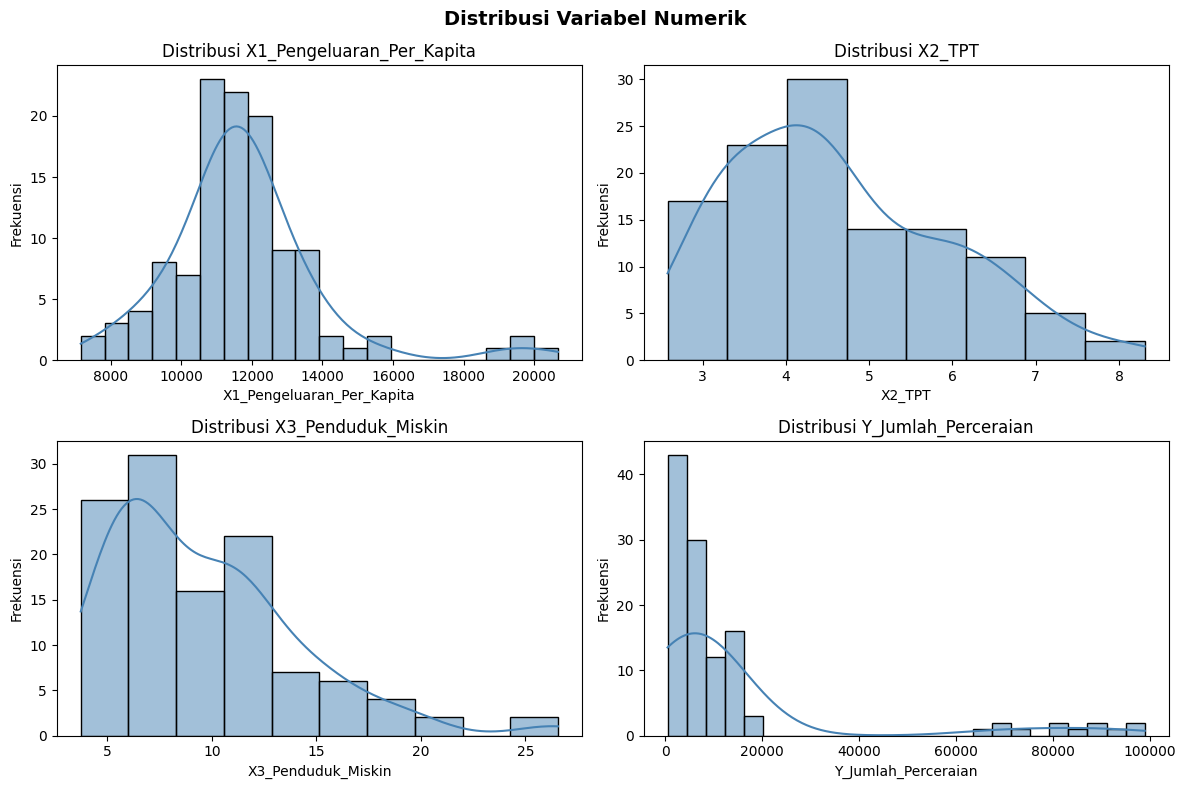

In [10]:
numerik_cols = ['X1_Pengeluaran_Per_Kapita', 'X2_TPT', 'X3_Penduduk_Miskin', 'Y_Jumlah_Perceraian']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), numerik_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

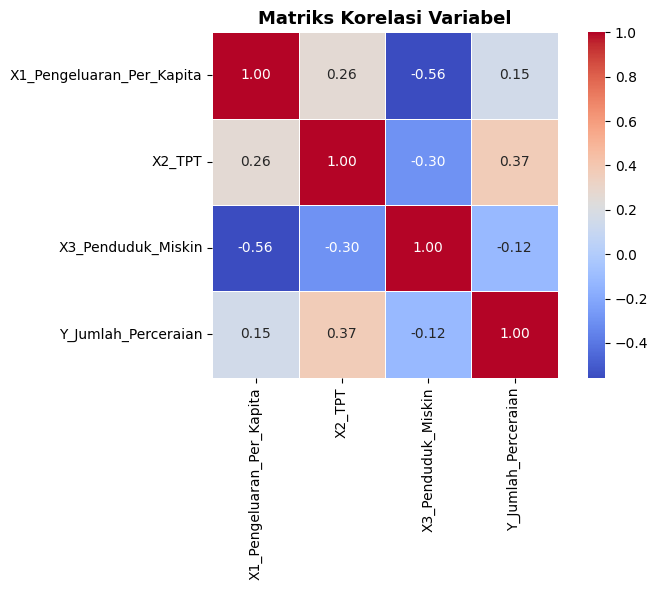


=== Nilai Korelasi terhadap Y_Jumlah_Perceraian ===
Y_Jumlah_Perceraian          1.000000
X2_TPT                       0.369088
X1_Pengeluaran_Per_Kapita    0.149066
X3_Penduduk_Miskin          -0.117109
Name: Y_Jumlah_Perceraian, dtype: float64


In [11]:
plt.figure(figsize=(8, 6))
corr_matrix = df[numerik_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Matriks Korelasi Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Nilai Korelasi terhadap Y_Jumlah_Perceraian ===")
print(corr_matrix['Y_Jumlah_Perceraian'].sort_values(ascending=False))

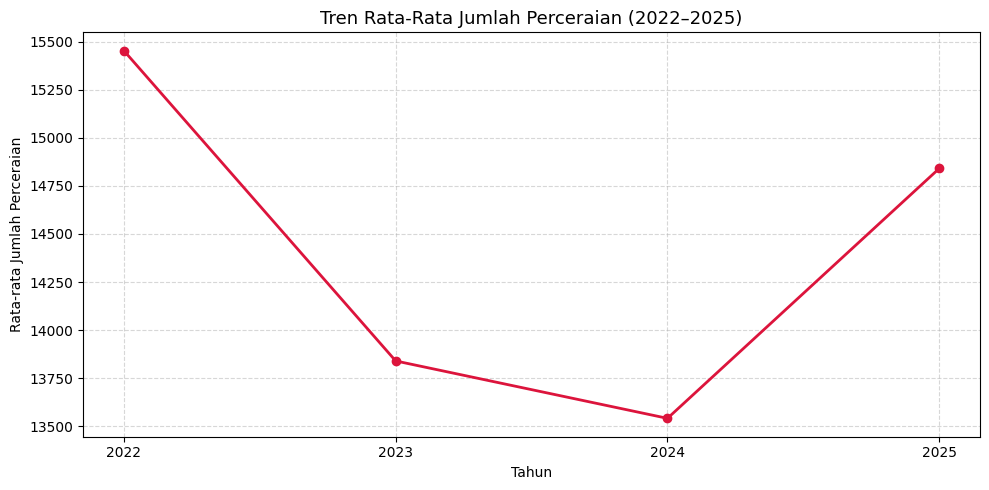

In [12]:
plt.figure(figsize=(10, 5))
trend = df.groupby('Tahun')['Y_Jumlah_Perceraian'].mean().reset_index()
plt.plot(trend['Tahun'], trend['Y_Jumlah_Perceraian'], marker='o', color='crimson', linewidth=2)
plt.title('Tren Rata-Rata Jumlah Perceraian (2022–2025)', fontsize=13)
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Jumlah Perceraian')
plt.xticks(trend['Tahun'].astype(int))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

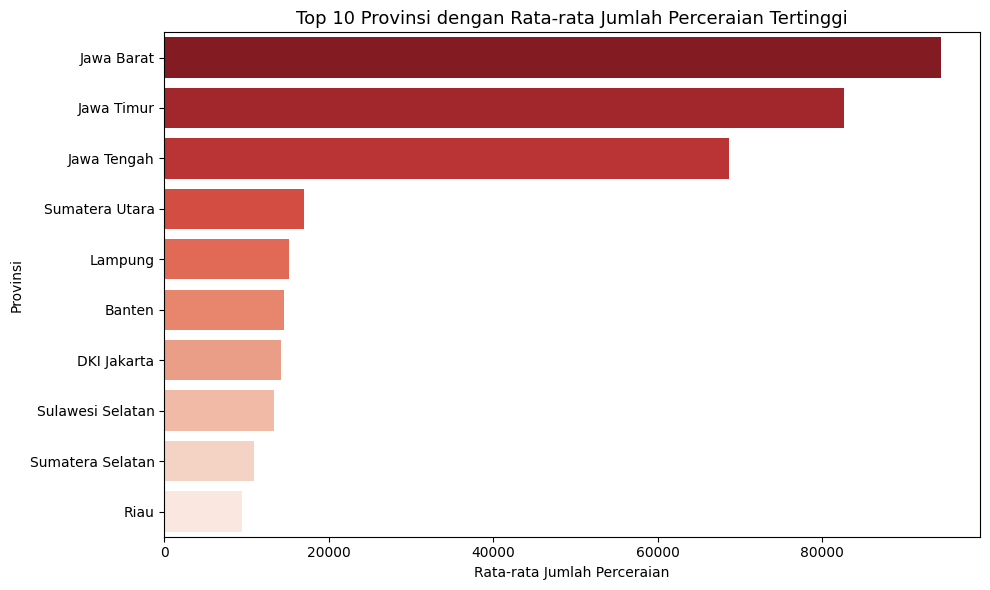

In [13]:
plt.figure(figsize=(10, 6))
top10 = df.groupby('Provinsi')['Y_Jumlah_Perceraian'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.title('Top 10 Provinsi dengan Rata-rata Jumlah Perceraian Tertinggi', fontsize=13)
plt.xlabel('Rata-rata Jumlah Perceraian')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

#  Data Preprocessing

In [14]:
print(f"Jumlah data sebelum pembersihan outlier: {len(df)}")

df_clean = df[(df['Y_Jumlah_Perceraian'] >= lower_bound) & (df['Y_Jumlah_Perceraian'] <= upper_bound)].copy()

print(f"Jumlah data setelah pembersihan outlier: {len(df_clean)}")
print(f"Data yang dihapus: {len(df) - len(df_clean)} baris")

Jumlah data sebelum pembersihan outlier: 116
Jumlah data setelah pembersihan outlier: 104
Data yang dihapus: 12 baris


In [15]:
X = df_clean[['X1_Pengeluaran_Per_Kapita', 'X2_TPT', 'X3_Penduduk_Miskin']]
y = df_clean['Y_Jumlah_Perceraian']

print("=== Variabel Prediktor (X) ===")
print(X.head())
print(f"\nShape X: {X.shape}")
print(f"\n=== Variabel Target (y) ===")
print(y.head())

=== Variabel Prediktor (X) ===
   X1_Pengeluaran_Per_Kapita  X2_TPT  X3_Penduduk_Miskin
0                     9963.0    6.17               14.64
1                    10334.0    6.03               14.45
2                    10811.0    5.75               12.64
3                    11191.0    5.64               12.22
4                    10848.0    6.16                8.42

Shape X: (104, 3)

=== Variabel Target (y) ===
0     6904.0
1     6086.0
2     6103.0
3     6471.0
4    17333.0
Name: Y_Jumlah_Perceraian, dtype: float64


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("=== Data Setelah Standardisasi ===")
print(X_scaled.describe().round(2))

=== Data Setelah Standardisasi ===
       X1_Pengeluaran_Per_Kapita  X2_TPT  X3_Penduduk_Miskin
count                     104.00  104.00              104.00
mean                        0.00   -0.00               -0.00
std                         1.00    1.00                1.00
min                        -2.00   -1.55               -1.25
25%                        -0.46   -0.87               -0.77
50%                        -0.11   -0.21               -0.36
75%                         0.32    0.70                0.55
max                         3.95    2.87                3.59


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Jumlah data latih (train) : {X_train.shape[0]} baris")
print(f"Jumlah data uji  (test)   : {X_test.shape[0]} baris")

Jumlah data latih (train) : 83 baris
Jumlah data uji  (test)   : 21 baris


#  Model Training

Persamaan umum regresi linear berganda:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \varepsilon$$

Di mana:
- $Y$ = Jumlah Perceraian
- $X_1$ = Pengeluaran Per Kapita
- $X_2$ = Tingkat Pengangguran Terbuka
- $X_3$ = Persentase Penduduk Miskin
- $\beta_0$ = Intercept (konstanta)
- $\beta_1, \beta_2, \beta_3$ = Koefisien regresi

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

print("=== PERSAMAAN REGRESI LINEAR BERGANDA ===")
print(f"Intercept (β₀) : {model.intercept_:.4f}")
print()
for nama, koef in zip(X.columns, model.coef_):
    print(f"Koefisien {nama} : {koef:.4f}")

y_pred = model.predict(X_test)

=== PERSAMAAN REGRESI LINEAR BERGANDA ===
Intercept (β₀) : 6416.5689

Koefisien X1_Pengeluaran_Per_Kapita : 1256.9032
Koefisien X2_TPT : 1350.1733
Koefisien X3_Penduduk_Miskin : -556.0841


In [19]:
b0 = model.intercept_
b1, b2, b3 = model.coef_

print("=== PERSAMAAN MODEL ===")
print(f"Y_Jumlah_Perceraian = {b0:.4f}")
print(f"                    + ({b1:.4f}) × X1_Pengeluaran_Per_Kapita")
print(f"                    + ({b2:.4f}) × X2_TPT")
print(f"                    + ({b3:.4f}) × X3_Penduduk_Miskin")

=== PERSAMAAN MODEL ===
Y_Jumlah_Perceraian = 6416.5689
                    + (1256.9032) × X1_Pengeluaran_Per_Kapita
                    + (1350.1733) × X2_TPT
                    + (-556.0841) × X3_Penduduk_Miskin


#  Visualisasi Hasil Prediksi

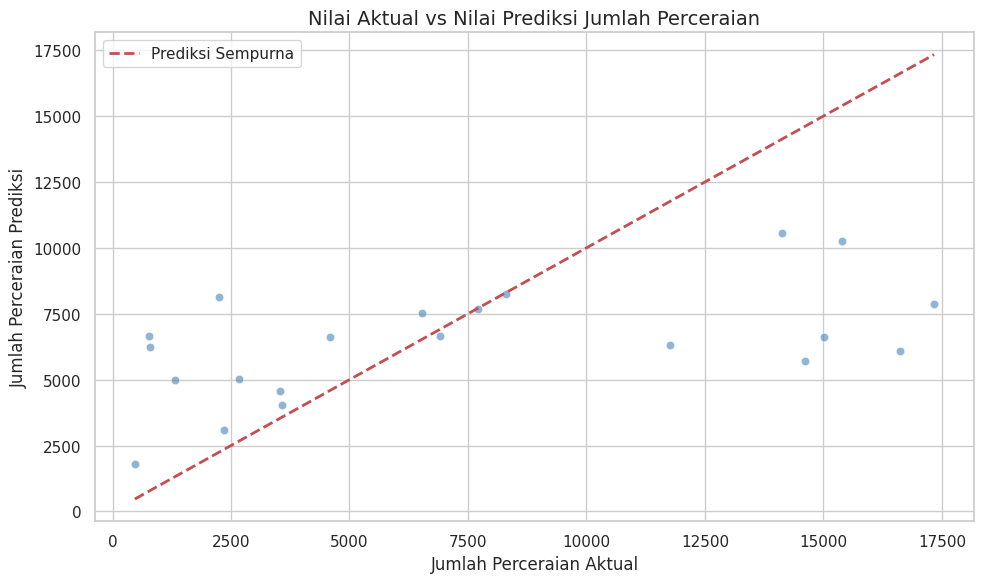

In [20]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediksi Sempurna')

plt.title('Nilai Aktual vs Nilai Prediksi Jumlah Perceraian', fontsize=14)
plt.xlabel('Jumlah Perceraian Aktual', fontsize=12)
plt.ylabel('Jumlah Perceraian Prediksi', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

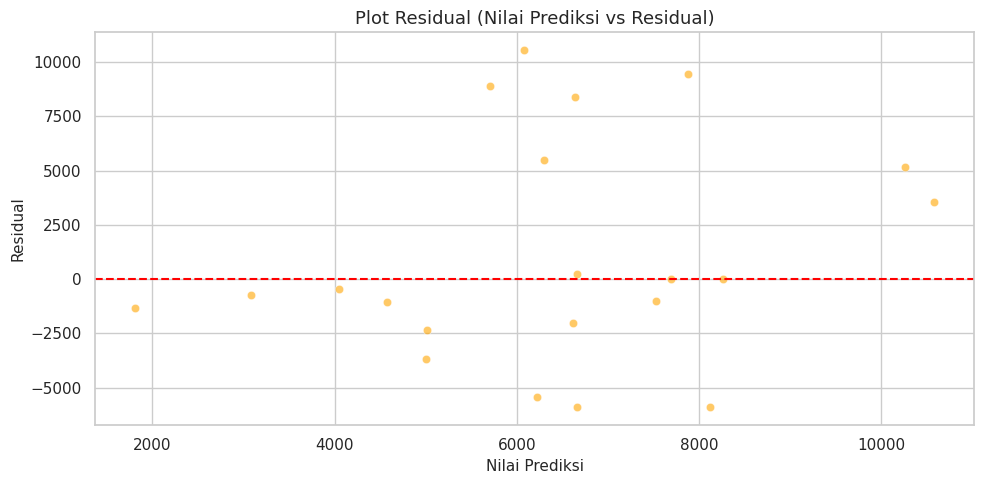

In [21]:
residual = y_test.values - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residual, alpha=0.6, color='orange', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Plot Residual (Nilai Prediksi vs Residual)', fontsize=13)
plt.xlabel('Nilai Prediksi', fontsize=11)
plt.ylabel('Residual', fontsize=11)
plt.tight_layout()
plt.show()

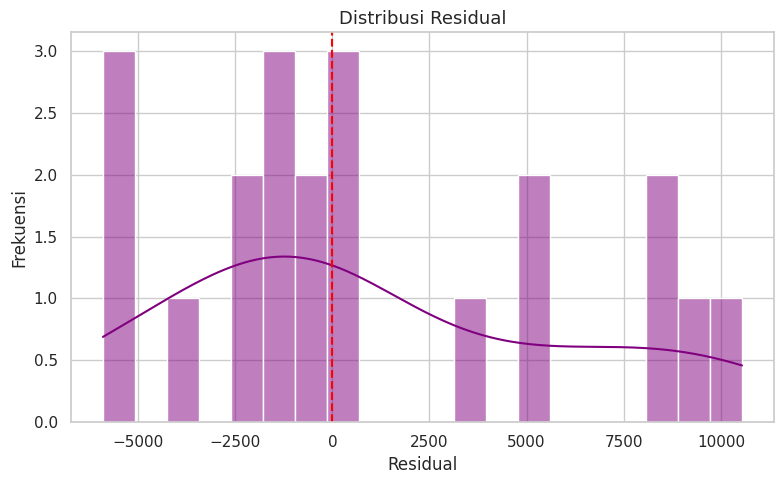

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(residual, kde=True, color='purple', bins=20)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribusi Residual', fontsize=13)
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

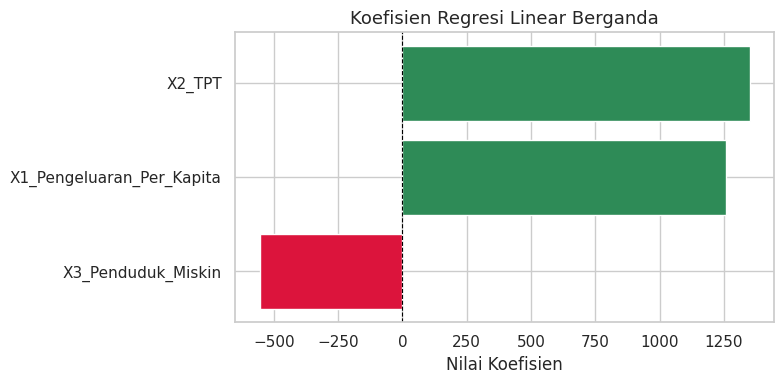

Interpretasi:
- Koefisien positif (hijau) → variabel meningkatkan jumlah perceraian
- Koefisien negatif (merah) → variabel menurunkan jumlah perceraian


In [23]:
koef_df = pd.DataFrame({
    'Variabel': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['crimson' if k < 0 else 'seagreen' for k in koef_df['Koefisien']]
plt.barh(koef_df['Variabel'], koef_df['Koefisien'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Koefisien Regresi Linear Berganda', fontsize=13)
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

print("Interpretasi:")
print("- Koefisien positif (hijau) → variabel meningkatkan jumlah perceraian")
print("- Koefisien negatif (merah) → variabel menurunkan jumlah perceraian")

#  Evaluasi Model

Evaluasi model dilakukan untuk mengukur seberapa baik model dalam memprediksi jumlah perceraian. Metrik yang digunakan:

| Metrik | Keterangan |
| ------ | ----------- |
| MAE    | Mean Absolute Error — rata-rata kesalahan absolut antara nilai aktual dan prediksi |
| MSE    | Mean Squared Error — rata-rata kuadrat kesalahan; memberi hukuman lebih pada error besar |
| RMSE   | Root Mean Squared Error — akar dari MSE; mudah diinterpretasikan karena satuannya sama dengan target |
| R²     | Koefisien determinasi — proporsi variansi target yang dapat dijelaskan oleh model (0–1, semakin mendekati 1 semakin baik) |

In [24]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===")
print(f"R²   (Koefisien Determinasi) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE  (Mean Absolute Error)   : {mae:.4f}")
print(f"MSE  (Mean Squared Error)    : {mse:.4f}")
print(f"RMSE (Root MSE)              : {rmse:.4f}")

print("\n=== INTERPRETASI ===")
if r2 >= 0.7:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi jumlah perceraian")
    print("dapat dijelaskan oleh variabel prediktor yang digunakan. Model CUKUP BAIK.")
elif r2 >= 0.5:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi jumlah perceraian")
    print("dapat dijelaskan oleh variabel prediktor. Model CUKUP MODERAT.")
else:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi jumlah perceraian")
    print("dapat dijelaskan oleh variabel prediktor. Perlu penambahan fitur atau transformasi data.")


=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===
R²   (Koefisien Determinasi) : 0.2295  (22.95%)
MAE  (Mean Absolute Error)   : 3883.7535
MSE  (Mean Squared Error)    : 25984877.5851
RMSE (Root MSE)              : 5097.5364

=== INTERPRETASI ===
Model memiliki R² = 0.23, artinya 23.0% variasi jumlah perceraian
dapat dijelaskan oleh variabel prediktor. Perlu penambahan fitur atau transformasi data.


In [25]:
hasil_uji = pd.DataFrame({
    'Jumlah Perceraian Aktual': y_test.values[:10],
    'Jumlah Perceraian Prediksi': np.round(y_pred[:10], 2),
    'Selisih (Error)': np.abs(y_test.values[:10] - y_pred[:10]).round(2)
})

print("=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===")
print(hasil_uji.to_string(index=False))

=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===
 Jumlah Perceraian Aktual  Jumlah Perceraian Prediksi  Selisih (Error)
                  14603.0                     5709.38          8893.62
                   6537.0                     7522.56           985.56
                   7706.0                     7696.44             9.56
                    471.0                     1808.14          1337.14
                  14133.0                    10578.83          3554.17
                    793.0                     6224.17          5431.17
                   2671.0                     5016.37          2345.37
                  15400.0                    10254.90          5145.10
                   8292.0                     8264.04            27.96
                   6904.0                     6661.34           242.66


#  Deployment / Prediksi Data Baru

In [26]:
print("=== SISTEM PREDIKSI JUMLAH PERCERAIAN ===")
print("Masukkan data berikut untuk memprediksi jumlah perceraian:")
print()

pengeluaran_per_kapita = 12000.0
tingkat_pengangguran   = 5.5
penduduk_miskin        = 9.0

print(f"Input Data Baru:")
print(f"  Pengeluaran Per Kapita      : {pengeluaran_per_kapita} Ribu Rp/Org/Thn")
print(f"  Tingkat Pengangguran Terbuka: {tingkat_pengangguran}%")
print(f"  Persentase Penduduk Miskin  : {penduduk_miskin}%")

data_baru = pd.DataFrame([{
    'X1_Pengeluaran_Per_Kapita': pengeluaran_per_kapita,
    'X2_TPT'                  : tingkat_pengangguran,
    'X3_Penduduk_Miskin'      : penduduk_miskin
}])

data_baru_scaled = scaler.transform(data_baru)

prediksi = model.predict(data_baru_scaled)[0]

print()
print("=" * 45)
print(f"HASIL PREDIKSI:")
print(f"  Jumlah Perceraian : {prediksi:.2f} perkara")
print("=" * 45)

rata_seluruh = df['Y_Jumlah_Perceraian'].mean()
print(f"\nRata-rata seluruh provinsi (2022-2025) : {rata_seluruh:.2f} perkara")

if prediksi > rata_seluruh:
    print(f"Prediksi MELEBIHI rata-rata → Jumlah Perceraian TINGGI")
else:
    print(f"Prediksi DI BAWAH rata-rata → Jumlah Perceraian RENDAH")

=== SISTEM PREDIKSI JUMLAH PERCERAIAN ===
Masukkan data berikut untuk memprediksi jumlah perceraian:

Input Data Baru:
  Pengeluaran Per Kapita      : 12000.0 Ribu Rp/Org/Thn
  Tingkat Pengangguran Terbuka: 5.5%
  Persentase Penduduk Miskin  : 9.0%

HASIL PREDIKSI:
  Jumlah Perceraian : 7727.80 perkara

Rata-rata seluruh provinsi (2022-2025) : 14418.71 perkara
Prediksi DI BAWAH rata-rata → Jumlah Perceraian RENDAH


In [27]:
# KESIMPULAN

print("=" * 55)
print("KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA")
print("=" * 55)
print()
print("Judul:")
print("  Analisis Regresi Linear Berganda untuk Memprediksi")
print("  Jumlah Perceraian di Indonesia Tahun 2022-2025")
print()
print("Variabel Prediktor (X):")
print("  1. Pengeluaran Per Kapita (X1_Pengeluaran_Per_Kapita)")
print("  2. Tingkat Pengangguran Terbuka (X2_TPT)")
print("  3. Persentase Penduduk Miskin (X3_Penduduk_Miskin)")
print()
print("Variabel Target (Y):")
print("  Jumlah Perceraian (Y_Jumlah_Perceraian)")
print()
print("Persamaan Model:")
print(f"  Y = {b0:.4f} + ({b1:.4f})×X₁ + ({b2:.4f})×X₂ + ({b3:.4f})×X₃")
print()
print("Hasil Evaluasi:")
print(f"  R²   = {r2:.4f}  → Model menjelaskan {r2*100:.2f}% variansi data")
print(f"  MAE  = {mae:.4f}  → Rata-rata kesalahan absolut")
print(f"  RMSE = {rmse:.4f}  → Ukuran error yang mudah diinterpretasikan")
print()
print("=" * 55)

KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA

Judul:
  Analisis Regresi Linear Berganda untuk Memprediksi
  Jumlah Perceraian di Indonesia Tahun 2022-2025

Variabel Prediktor (X):
  1. Pengeluaran Per Kapita (X1_Pengeluaran_Per_Kapita)
  2. Tingkat Pengangguran Terbuka (X2_TPT)
  3. Persentase Penduduk Miskin (X3_Penduduk_Miskin)

Variabel Target (Y):
  Jumlah Perceraian (Y_Jumlah_Perceraian)

Persamaan Model:
  Y = 6416.5689 + (1256.9032)×X₁ + (1350.1733)×X₂ + (-556.0841)×X₃

Hasil Evaluasi:
  R²   = 0.2295  → Model menjelaskan 22.95% variansi data
  MAE  = 3883.7535  → Rata-rata kesalahan absolut
  RMSE = 5097.5364  → Ukuran error yang mudah diinterpretasikan

